<a href="https://colab.research.google.com/github/Keke0603/Applied-AI/blob/main/transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving dataset.zip.zip to dataset.zip (1).zip
Archive:  dataset.zip (1).zip
  inflating: dataset.zip/person1/76thh2qo_priyanka-chopra_625x300_28_March_23.webp  
  inflating: dataset.zip/person1/Priyanka-Chopra.jpg  
  inflating: dataset.zip/person2/4b4d6d67ae25a39614d161dc6a274838.jpg  
  inflating: dataset.zip/person2/Nick-Jonas-e1718204992839.webp  
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Embeddings shape: (4, 512)
Accuracy: 100.0


Saving nicktest.webp to nicktest.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


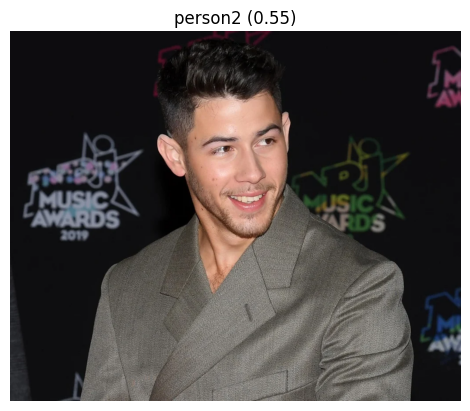

In [2]:
!pip install mtcnn keras-facenet opencv-python matplotlib scikit-learn

import cv2
import numpy as np
import os
from mtcnn import MTCNN
from keras_facenet import FaceNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from google.colab import files

detector = MTCNN()
embedder = FaceNet()

def extract_face(image, size=(160,160)):
    results = detector.detect_faces(image)
    if len(results) == 0:
        return None
    x,y,w,h = results[0]['box']
    x,y = abs(x), abs(y)
    face = image[y:y+h, x:x+w]
    face = cv2.resize(face, size)
    return face

def get_embedding(face):
    face = face.astype('float32')
    face = np.expand_dims(face, axis=0)
    embedding = embedder.embeddings(face)
    return embedding[0]

def load_dataset(directory):
    embeddings = []
    labels = []
    for person in os.listdir(directory):
        person_path = os.path.join(directory, person)
        if not os.path.isdir(person_path):
            continue
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            face = extract_face(image)
            if face is None:
                continue
            embedding = get_embedding(face)
            embeddings.append(embedding)
            labels.append(person)
    return np.array(embeddings), np.array(labels)

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

!rm -rf /content/dataset
!unzip -o "$zip_name"

folders = [f for f in os.listdir('/content') if os.path.isdir(f) and f not in ['.config','sample_data']]
dataset_path = os.path.join('/content', folders[0])

X, y = load_dataset(dataset_path)

print("Embeddings shape:", X.shape)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100)

uploaded = files.upload()

for file in uploaded.keys():
    img = cv2.imread(file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    face = extract_face(img)
    if face is None:
        print("No face detected")
        continue
    embedding = get_embedding(face)
    embedding = np.expand_dims(embedding, axis=0)
    pred = model.predict(embedding)
    prob = model.predict_proba(embedding)
    label = encoder.inverse_transform(pred)[0]
    confidence = np.max(prob)
    plt.imshow(img)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis('off')
    plt.show()